# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [11]:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})

elm__7         itu-glass
no-name-1      itu-concrete
Directivity [dB]: 2.15
Gain [dB]: 2.16
Efficiency [%]: 1e+02
([1.64091], [1.643], [1.00128])
[[0, -0.0642857, 0],
 [0, -0.0214286, 0],
 [0, 0.0214286, 0],
 [0, 0.0642857, 0]]


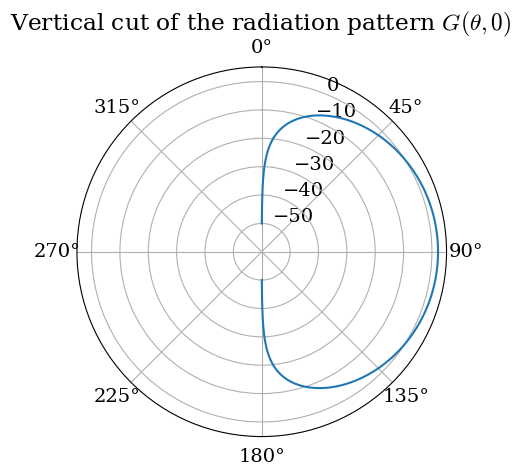

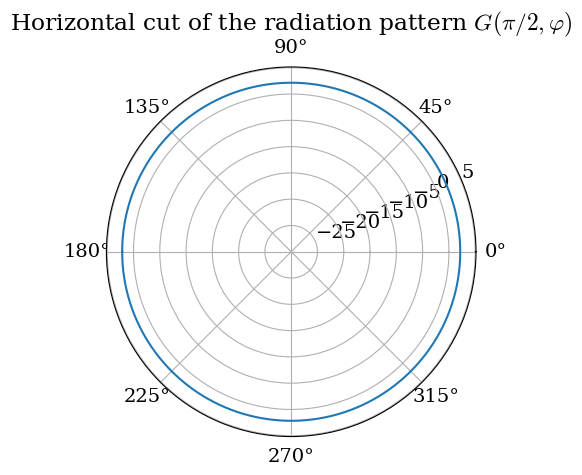

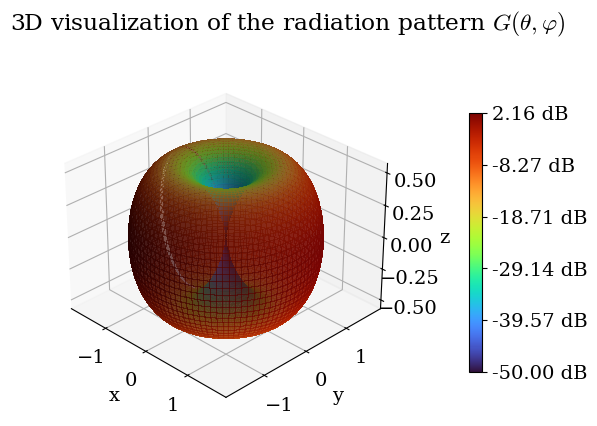

TraitError: The 'rotation' trait of a PerspectiveCamera instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

TraitError: The 'rotation' trait of a PerspectiveCamera instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

In [3]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='hw_dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='hw_dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())
print(scene.rx_array.positions(3e8/3.5e9))
scene.rx_array.antenna_pattern.show()

# Tx position
TX_position = [5.5, 0, 1.5]

tx = Transmitter("tx", TX_position)
scene.add(tx)

# Rx positions
num_rx = 8
RX_positions = [[-7, 8, 1.5], 
                [0, 8, 1.5], 
                [7, 8, 1.5], 
                [9, 0, 1.5], 
                [-9, 0, 1.5], 
                [-7, -8, 1.5], 
                [0, -8, 1.5], 
                [7, -8, 1.5]]

# num_rx = 4
# RX_positions = [[-7, 8, 1.5], 
#                 [7, 8, 1.5],
#                 [-7, -8, 1.5],
#                 [7, -8, 1.5]]

RX_orientations = [[-np.pi/4, 0, 0], 
                   [-np.pi/2, 0, 0], 
                   [-3*np.pi/4, 0, 0], 
                   [np.pi, 0, 0], 
                   [0, 0, 0], 
                   [np.pi/4, 0, 0], 
                   [np.pi/2, 0, 0], 
                   [3*np.pi/4, 0, 0]]

# RX_orientations = [[-np.pi/4, 0, 0], 
#                     [-3*np.pi/4, 0, 0], 
#                     [np.pi/4, 0, 0],
#                     [3*np.pi/4, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

In [14]:
### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

### Paths computations ###

In [15]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.1 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [6]:
scene.preview(paths=paths)

In [7]:
import mitsuba as mi
import numpy as np
import plotly.graph_objects as go

# Create the figure
fig = go.Figure()

# --- STEP 1: Plot the Walls / Buildings ---
params = mi.traverse(scene._scene)
for key in params.keys():
    if key.endswith('.vertex_positions'):
        mesh_name = key.split('.')[0]
        v_flat = params[key].numpy()
        vertices = v_flat.reshape(-1, 3)
        
        f_key = f"{mesh_name}.faces"
        if f_key in params:
            f_flat = params[f_key].numpy()
            faces = f_flat.reshape(-1, 3)
            
            if mesh_name == "elm__7":  # Ground plane
                fig.add_trace(go.Mesh3d(
                    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
                    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                    name='Ground',
                    opacity=0.8,            
                    color="#41A8FC", 
                    flatshading=True,
                    hoverinfo='name'
                ))
            else:  # Other walls/buildings
                fig.add_trace(go.Mesh3d(
                    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
                    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                    name=mesh_name.replace('mesh-', ''),
                    opacity=1,            
                    color="#C4C4C4", 
                    flatshading=True,
                    hoverinfo='name'
                ))

# --- STEP 2 & 3: Antennas and Multi-Receiver Rays ---
path_vertices = paths.vertices.numpy()
is_valid = paths.valid.numpy()
interactions = paths.interactions.numpy()

tx_list = list(scene.transmitters.values())
rx_list = list(scene.receivers.values())

tx_coords = [tx.position.numpy().flatten() for tx in tx_list]
rx_coords = [rx.position.numpy().flatten() for rx in rx_list]

TX_positions = np.zeros((8, 5, 3))
x_axis = np.linspace(-7, 7, 8)
y_axis = np.linspace(-4, 4, 5)
x_axis, y_axis = np.meshgrid(x_axis, y_axis, indexing='ij')
TX_positions[:, :, 0] = x_axis
TX_positions[:, :, 1] = y_axis
TX_positions[:, :, 2] = 1.5

for i, tx_position in enumerate(TX_positions.reshape(-1, 3)):
    fig.add_trace(go.Scatter3d(
        x=[tx_position[0]], y=[tx_position[1]], z=[tx_position[2]],
        mode='markers', name=f'Tx Position', showlegend=(i == 0),
        marker=dict(size=6, color="#FF2600", symbol='circle')
    ))

# Plot Transmitters
# for t_idx, tx in enumerate(tx_list):
#     fig.add_trace(go.Scatter3d(
#         x=[tx_coords[t_idx][0]], y=[tx_coords[t_idx][1]], z=[tx_coords[t_idx][2]],
#         mode='markers', name=f'Tx',
#         marker=dict(size=8, color="#FF2600", symbol='circle')
#     ))

# Plot Receivers
for r_idx, rx in enumerate(rx_list):
    fig.add_trace(go.Scatter3d(
        x=[rx_coords[r_idx][0]], y=[rx_coords[r_idx][1]], z=[rx_coords[r_idx][2]],
        mode='markers', legendgroup='Rx', name=f'Rx', showlegend=(r_idx == 0),
        marker=dict(size=8, color="#34E724", symbol='circle')
    ))

# 2. Force the arrays into the exact dimensions we need
num_rx = len(rx_list)
num_tx = len(tx_list)
num_paths = is_valid.shape[-1]         
max_depth = interactions.shape[0]      

v_sq = np.zeros((num_rx, num_tx, num_paths, max_depth, 3))
val_sq = np.zeros((num_rx, num_tx, num_paths))
int_sq = np.zeros((num_rx, num_tx, num_paths, max_depth))

for r in range(num_rx):
    for t in range(num_tx):
        for p in range(num_paths):
            v_sq[r, t, p] = path_vertices[:, r, t, p, :]
            val_sq[r, t, p] = is_valid[r, t, p]
            int_sq[r, t, p] = interactions[:, r, t, p]

# --- Setup for Colors and Legends ---
rx_colors = ['rgb(255, 215, 0)',   # Gold
             'rgb(0, 255, 255)',   # Cyan
             'rgb(255, 105, 180)', # Hot Pink
             "#40FF40",   # Lime Green
             'rgb(147, 112, 219)'] # Purple

legend_added = {r: False for r in range(num_rx)}

# 3. Iterate through the grid and pair every ray to its correct Rx and Tx
for r in range(0, 0):
    current_rx_pos = rx_coords[r] 
    
    for t in range(num_tx):
        current_tx_pos = tx_coords[t] 
        
        for p in range(num_paths):
            if val_sq[r, t, p]: 
                ray_bounces = v_sq[r, t, p]
                interacts = int_sq[r, t, p]
                
                num_bounces = np.sum(interacts != 0)
                valid_bounces = ray_bounces[:num_bounces]
                full_path = np.vstack([current_tx_pos, valid_bounces, current_rx_pos])

                color = rx_colors[r % len(rx_colors)]
                show_leg = not legend_added[r]
                if show_leg:
                    legend_added[r] = True

                fig.add_trace(go.Scatter3d(
                    x=full_path[:, 0], y=full_path[:, 1], z=full_path[:, 2],
                    mode='lines',
                    name=f'Rays to Rx{r+1}',      
                    legendgroup=f'Rx_{r+1}',       
                    showlegend=show_leg,         
                    line=dict(color=color, width=2.5),
                    hoverinfo='name' 
                ))

# --- STEP 4: Minimalist White Layout & Export ---
fig.update_layout(
    paper_bgcolor='white', # Sets the canvas background to white
    plot_bgcolor='white',  # Sets the plotting area to white
    scene=dict(
        aspectmode='data', 
        
        # Completely strips grids, backgrounds, titles, and numbers from all axes
        xaxis=dict(showgrid=False, showbackground=False, showticklabels=False, title=''),
        yaxis=dict(showgrid=False, showbackground=False, showticklabels=False, title=''),
        zaxis=dict(showgrid=False, showbackground=False, showticklabels=False, title='')
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    showlegend=True
)

# Show the interactive plot in the notebook
fig.show()


In [42]:
# Define your perfect camera angle
my_camera = dict(
    up=dict(x=0, y=0, z=1),       # Which way is "up"
    center=dict(x=0, y=-0.2, z=0),   # Where the camera is looking
    eye=dict(x=0, y=-1, z=2.5)  # Where the camera is located (zoom and rotation)
)

fig.update_layout(
    scene_camera=my_camera,       # Apply the camera!
    paper_bgcolor='white', 
    plot_bgcolor='white',
    font=dict(size=20, family='serif'),
    # ... (rest of your layout)
)

In [ ]:
# fig.write_image("rt-small-scene_txpositions.pdf")

[-0.          0.67358632  1.34717262  2.02075893]
[ 0.          1.77979447 -2.72359625 -0.94380176]
[-0.          1.77400616 -2.73517289 -0.96116675]
[-0. -0. -0. -0.]
[0. 0. 0. 0.]
[-0.         -0.67358636 -1.34717259 -2.02075895]
[-0.         -1.77980903  2.72356729  0.94375829]
[ 0.         -1.77400437  2.73517681  0.96117243]


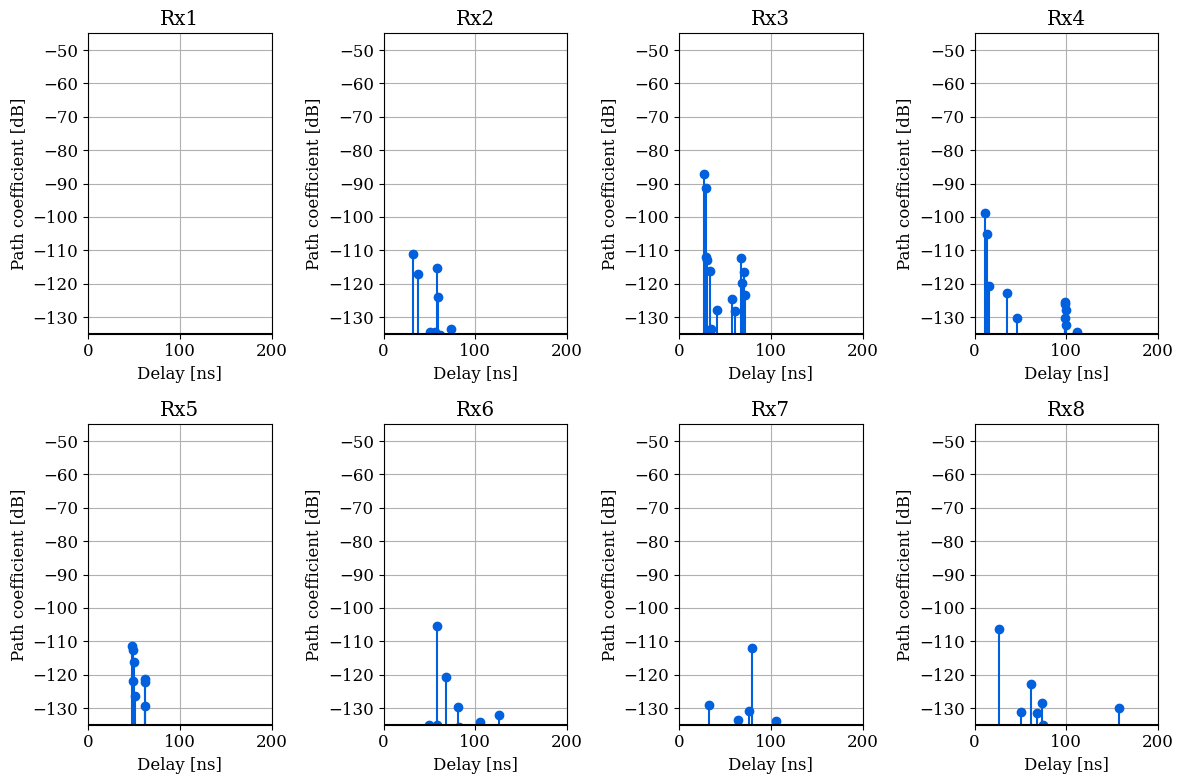

In [24]:
importlib.reload(util)

# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)

# Scale a with transmit power
a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

for i in range(len(a)):
    print(np.angle(a[i][:, 0] / a[i][0, 0]))

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(num_rx)]
energies = [magnitudes[i]**2 for i in range(num_rx)]


# Filter paths too weak
threshold = -145 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(num_rx):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)


fig, ax = plt.subplots(2, num_rx//2, figsize=(12, 8))
for i in range(num_rx):
    if energies[i].shape[1] == 0:
        continue
    markerline, stemlines, baseline = ax[i//(num_rx//2), i%(num_rx//2)].stem(
        tau[i]*1e9, 10*np.log10(energies[i][0]), linefmt="#0060DE", markerfmt='o', basefmt='k-', bottom=-135)
    baseline.set_visible(False)
    ax[i//(num_rx//2), i%(num_rx//2)].axhline(-135, color='black')
    ax[i//(num_rx//2), i%(num_rx//2)].set_title(f"Rx{i+1}")
    ax[i//(num_rx//2), i%(num_rx//2)].set_xlabel("Delay [ns]")
    ax[i//(num_rx//2), i%(num_rx//2)].set_ylabel("Path coefficient [dB]")
    ax[i//(num_rx//2), i%(num_rx//2)].set_xlim(0, 200)
    ax[i//(num_rx//2), i%(num_rx//2)].set_ylim(-135, -45)
    ax[i//(num_rx//2), i%(num_rx//2)].grid()
plt.tight_layout()
# plt.savefig("rt-small-cir2.pdf", bbox_inches='tight')

1.466456098222139e-05
1.3570311742046501e-05


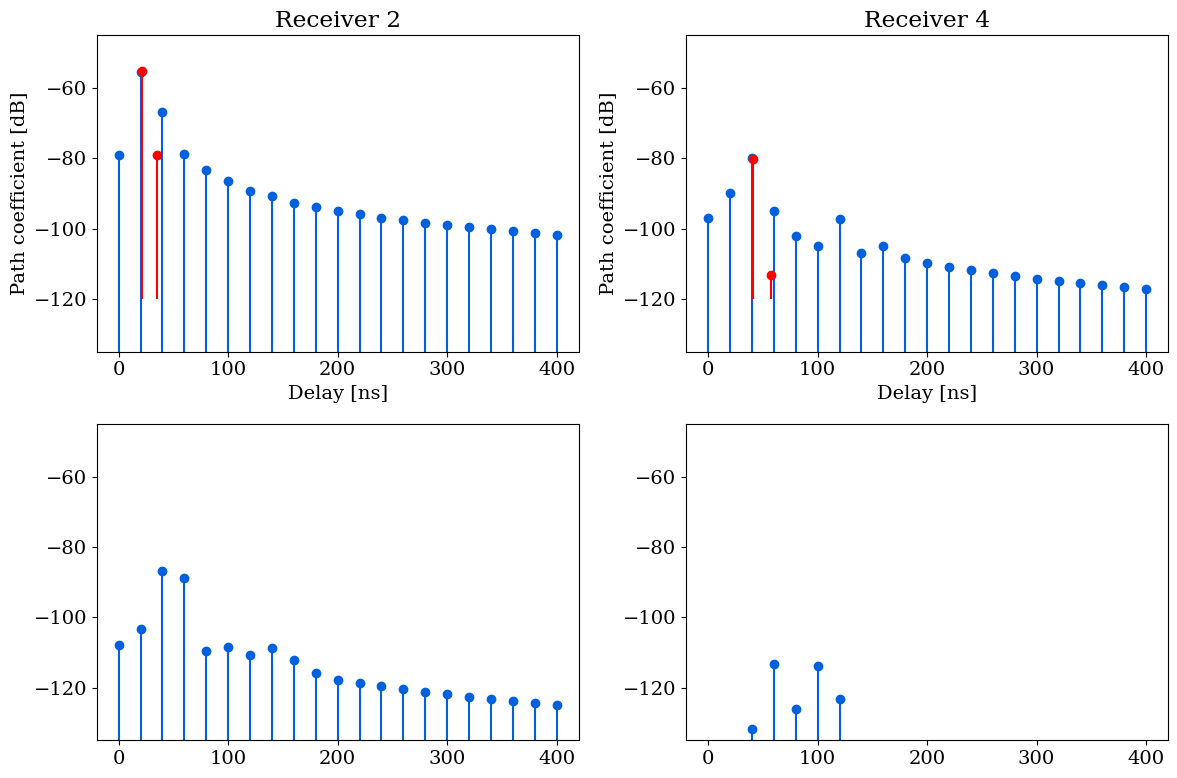

In [111]:
# Channel impulse response of the path
l_min, l_max = 0, 20
t = np.arange(l_min, l_max+1) / B

taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_energy = taps_mag ** 2


print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


fig, ax = plt.subplots(2, num_rx//2, figsize=(12, 8))
for i in range(num_rx):    
    markerline, stemlines, baseline = ax[i//(num_rx//2), i%(num_rx//2)].stem(
        t*1e9, 10*np.log10(taps_energy[i][0]), linefmt="#0060DE", markerfmt='o', basefmt='k-', bottom=-135)
    baseline.set_visible(False)
    ax[i//num_rx//2, i%num_rx//2].stem(tau[i][0]*1e9, 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    ax[i//num_rx//2, i%num_rx//2].set_title(f"Receiver {i+1}")
    ax[i//num_rx//2, i%num_rx//2].set_xlabel("Delay [ns]")
    ax[i//num_rx//2, i%num_rx//2].set_ylabel("Path coefficient [dB]")
    ax[i//num_rx//2, i%num_rx//2].set_xlim((l_min-1)/B*1e9, (l_max+1)/B*1e9)
    # ax[i//(num_rx//2), i%(num_rx//2)].set_xlim(0, 300)
    ax[i//(num_rx//2), i%(num_rx//2)].set_ylim(-135, -45)
    ax[i//num_rx//2, i%num_rx//2].grid()
plt.tight_layout()

In [57]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)

B = 100e6
fft_size = 256
RX_idx = 1
music_spectrum, music_tau, music_angles, K, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


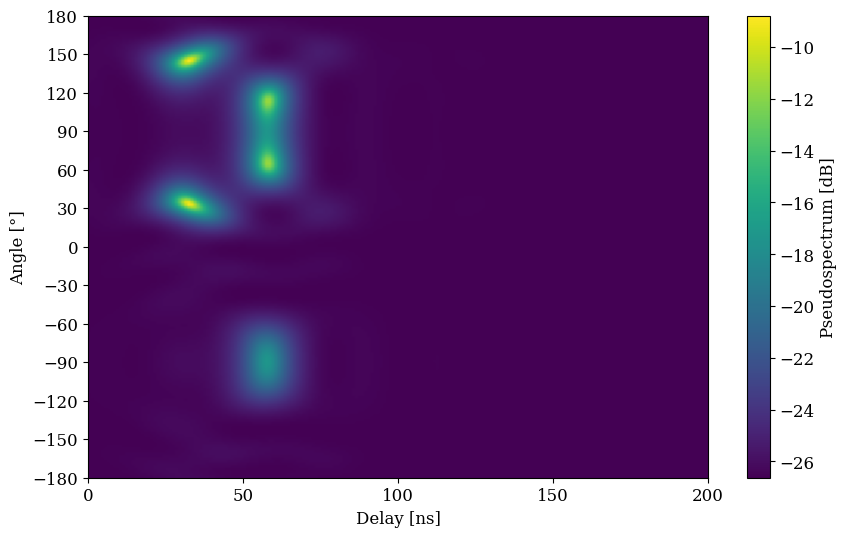

In [58]:
local_angles = util.format_local_angles(angles, RX_orientations)

plt.figure(figsize=(10, 6))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0]*1e9, music_tau[-1]*1e9, music_angles[0]*180/np.pi, music_angles[-1]*180/np.pi), aspect='auto', origin='lower')
# plt.scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
# plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay [ns]")
plt.ylabel("Angle [°]")
plt.xticks(np.arange(0, 201, 50))
plt.yticks(np.arange(-180, 181, 30))
plt.colorbar(label='Pseudospectrum [dB]')
# plt.savefig("music_2d_spectrum_bis.pdf", bbox_inches='tight')
plt.show()

In [28]:
importlib.reload(mp)
importlib.reload(com)

music_spectrums = []
music_taus = []
music_angles = []
music_Ks = []
music_h_hats = []
for RX_idx in range(num_rx):
    music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
    music_spectrums.append(music_spectrum)
    music_taus.append(music_tau)
    music_angles.append(music_angle)
    music_Ks.append(music_K)
    music_h_hats.append(music_h_hat)

C:\Users\louis\AppData\Local\Temp\ipykernel_11456\699551221.py:3: RuntimeWarning: divide by zero encountered in log10
  ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower', cmap='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_11456\699551221.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[RX_idx//2, RX_idx%2].legend()


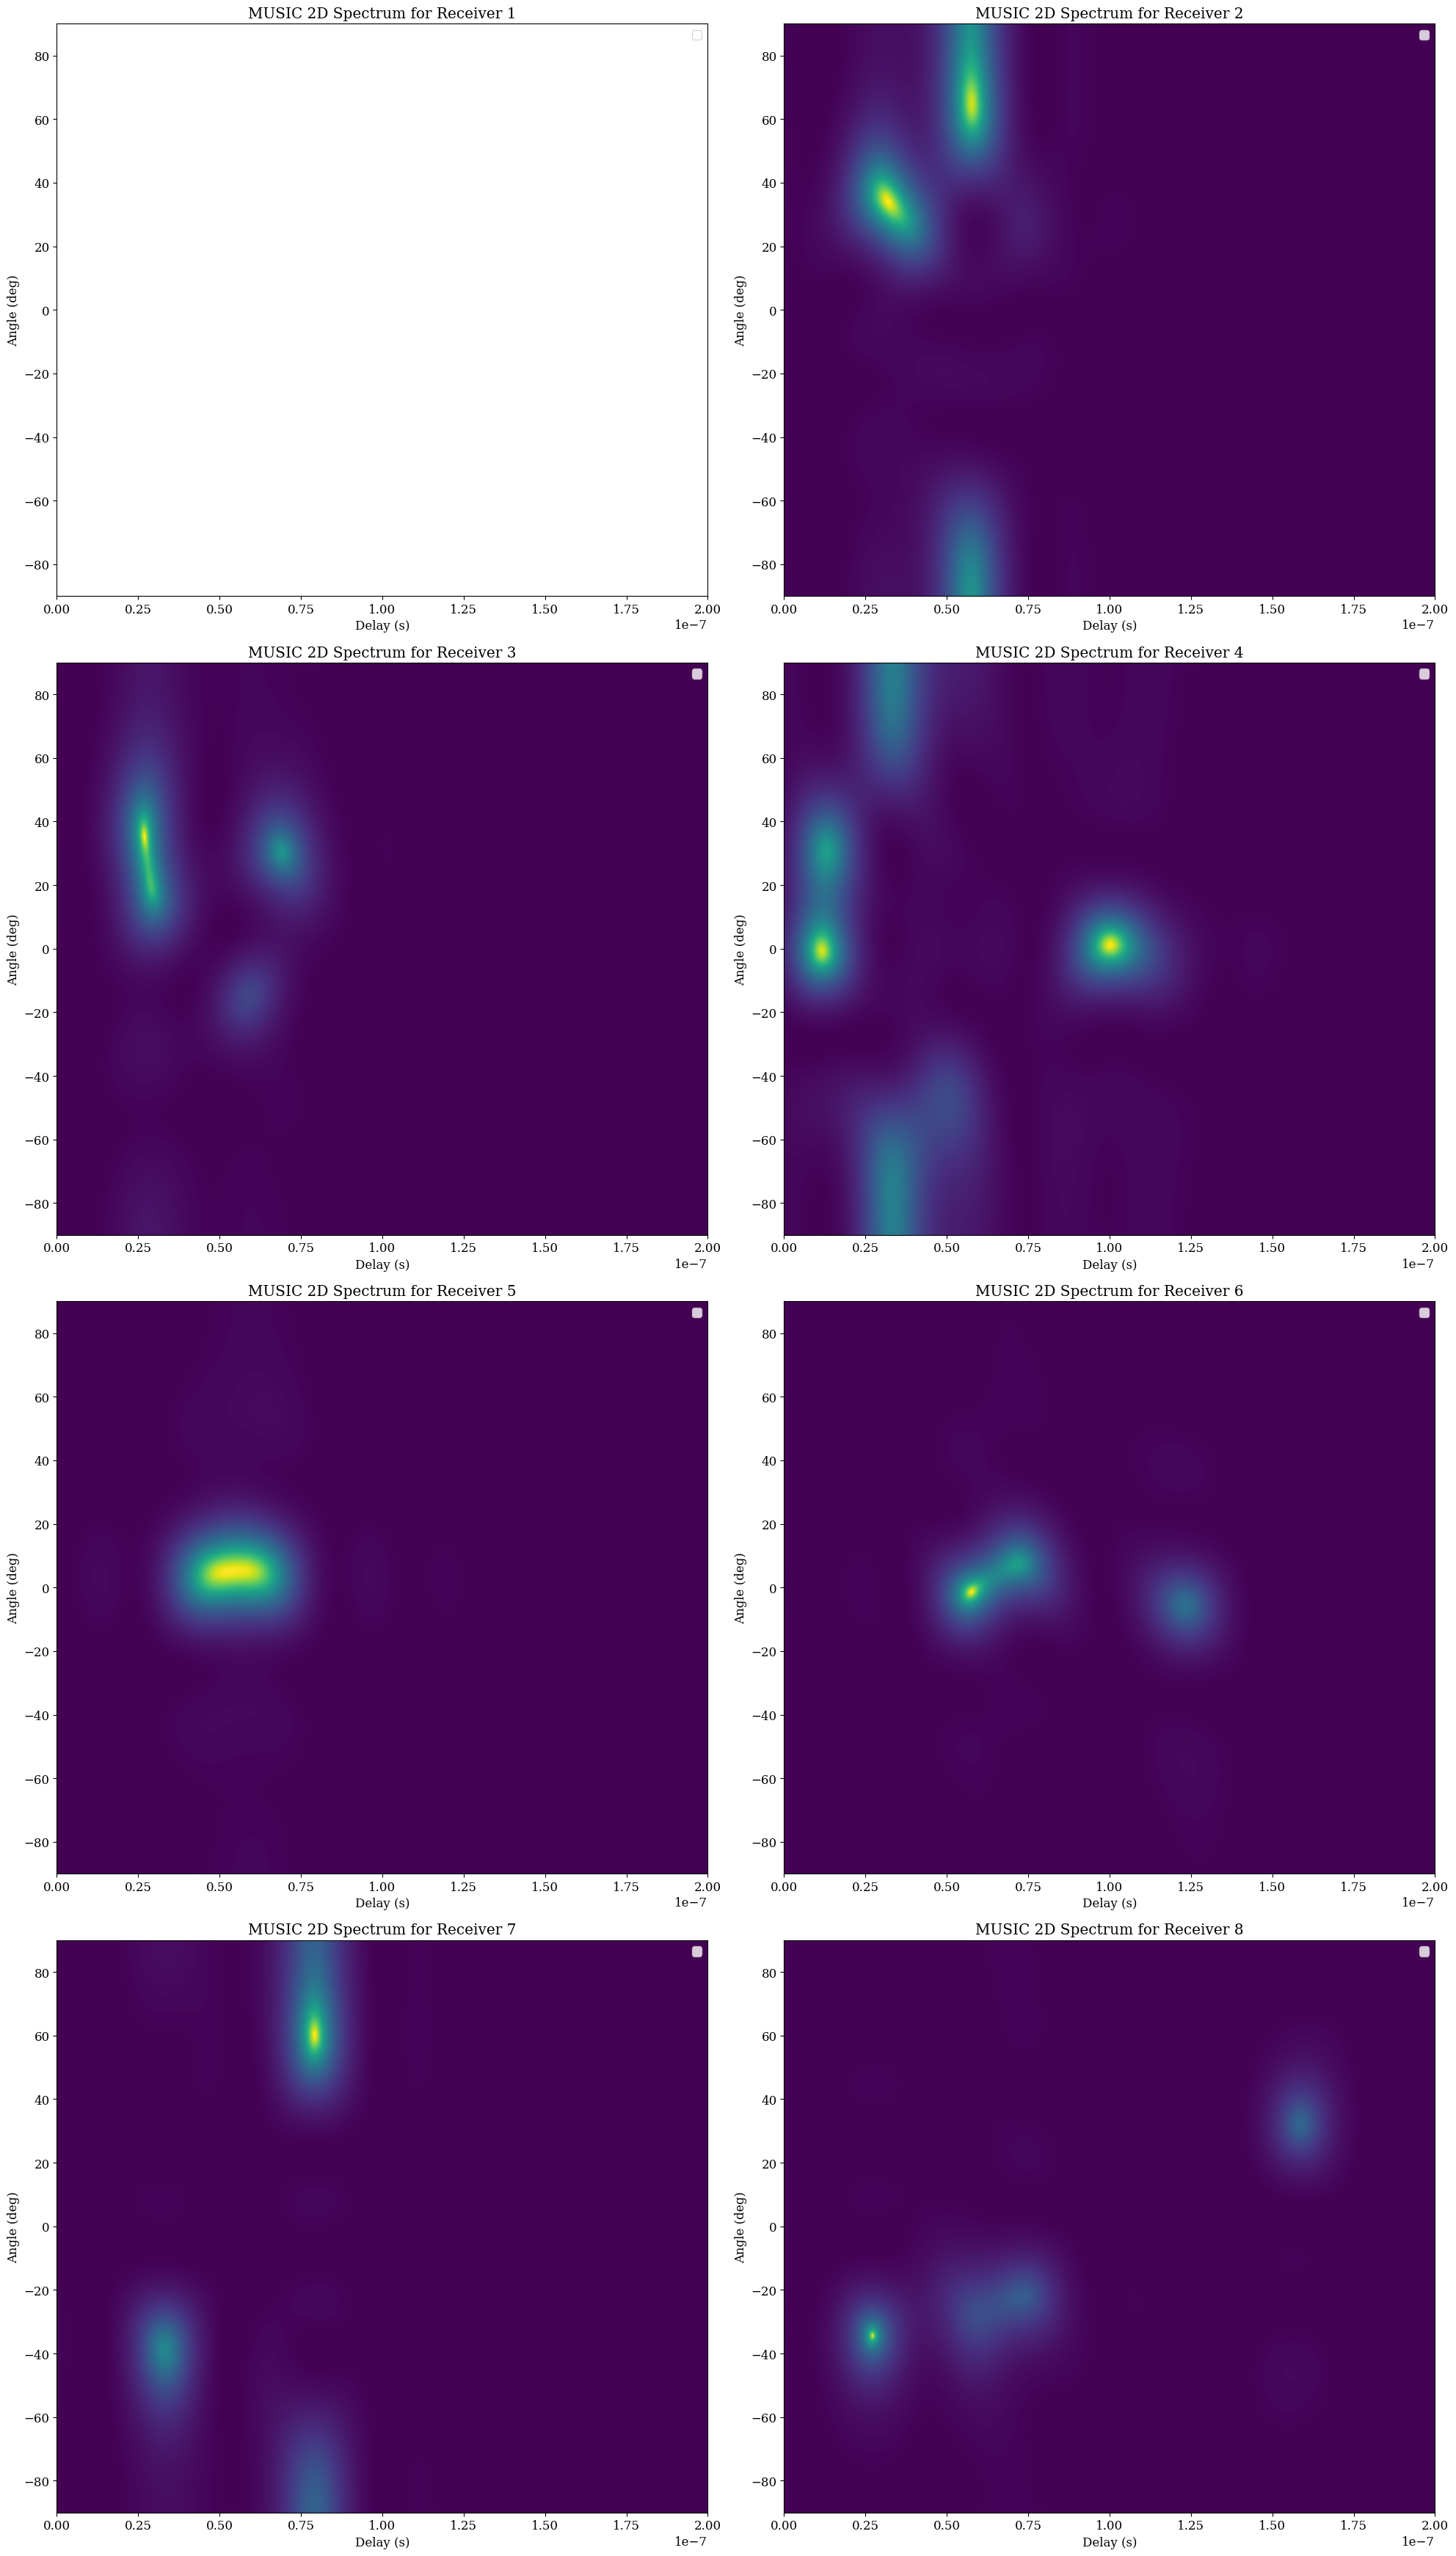

In [ ]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower', cmap='viridis')
    # ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

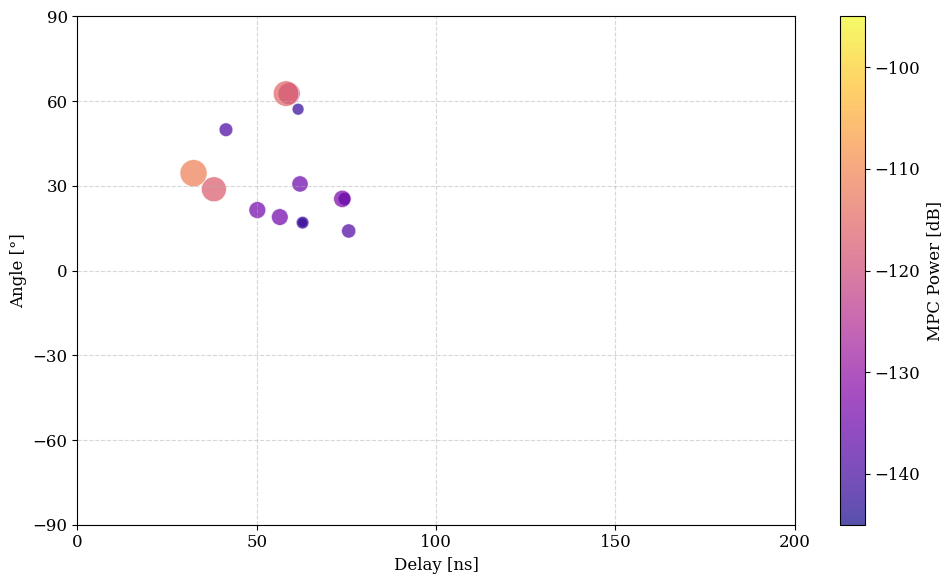

In [59]:
Rx_idx = 1

# 2. Convert amplitudes to dB (Power)
amplitudes_db = 20 * np.log10(magnitudes[Rx_idx][0] + 1e-10)

sort_idx = np.argsort(amplitudes_db)
delays_sorted = tau[Rx_idx][sort_idx]
angles_sorted = local_angles[Rx_idx][sort_idx]

# 3. Normalize sizes for the scatter plot markers
# We subtract the minimum to ensure all sizes are positive, then scale up
min_db = np.min(amplitudes_db)
sizes = (amplitudes_db - min_db + 5) * 10 

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Use scatter with both 'c' (color) and 's' (size) mapped to amplitude
scatter = plt.scatter(delays_sorted, angles_sorted*180/np.pi, 
                      c=amplitudes_db[sort_idx], 
                      s=sizes[sort_idx], 
                      cmap='plasma',     # 'magma' or 'viridis' look great for power
                      alpha=0.7,        # Slight transparency for overlapping taps
                      edgecolors='white', 
                      linewidth=0.5,
                      vmin= -145, vmax=-95)  # Set color limits for better contrast

# 5. Formatting
cbar = plt.colorbar(scatter)
cbar.set_label('MPC Power [dB]')

plt.xlabel('Delay [ns]')
plt.ylabel('Angle [°]')

plt.xlim(0, 200e-9)
plt.ylim(-90, 90)

plt.xticks(np.arange(0, 201e-9, 50e-9), labels=[0, 50, 100, 150, 200])
plt.yticks(np.arange(-90, 91, 30))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# plt.savefig("music_true_paths.pdf", bbox_inches='tight')
plt.show()

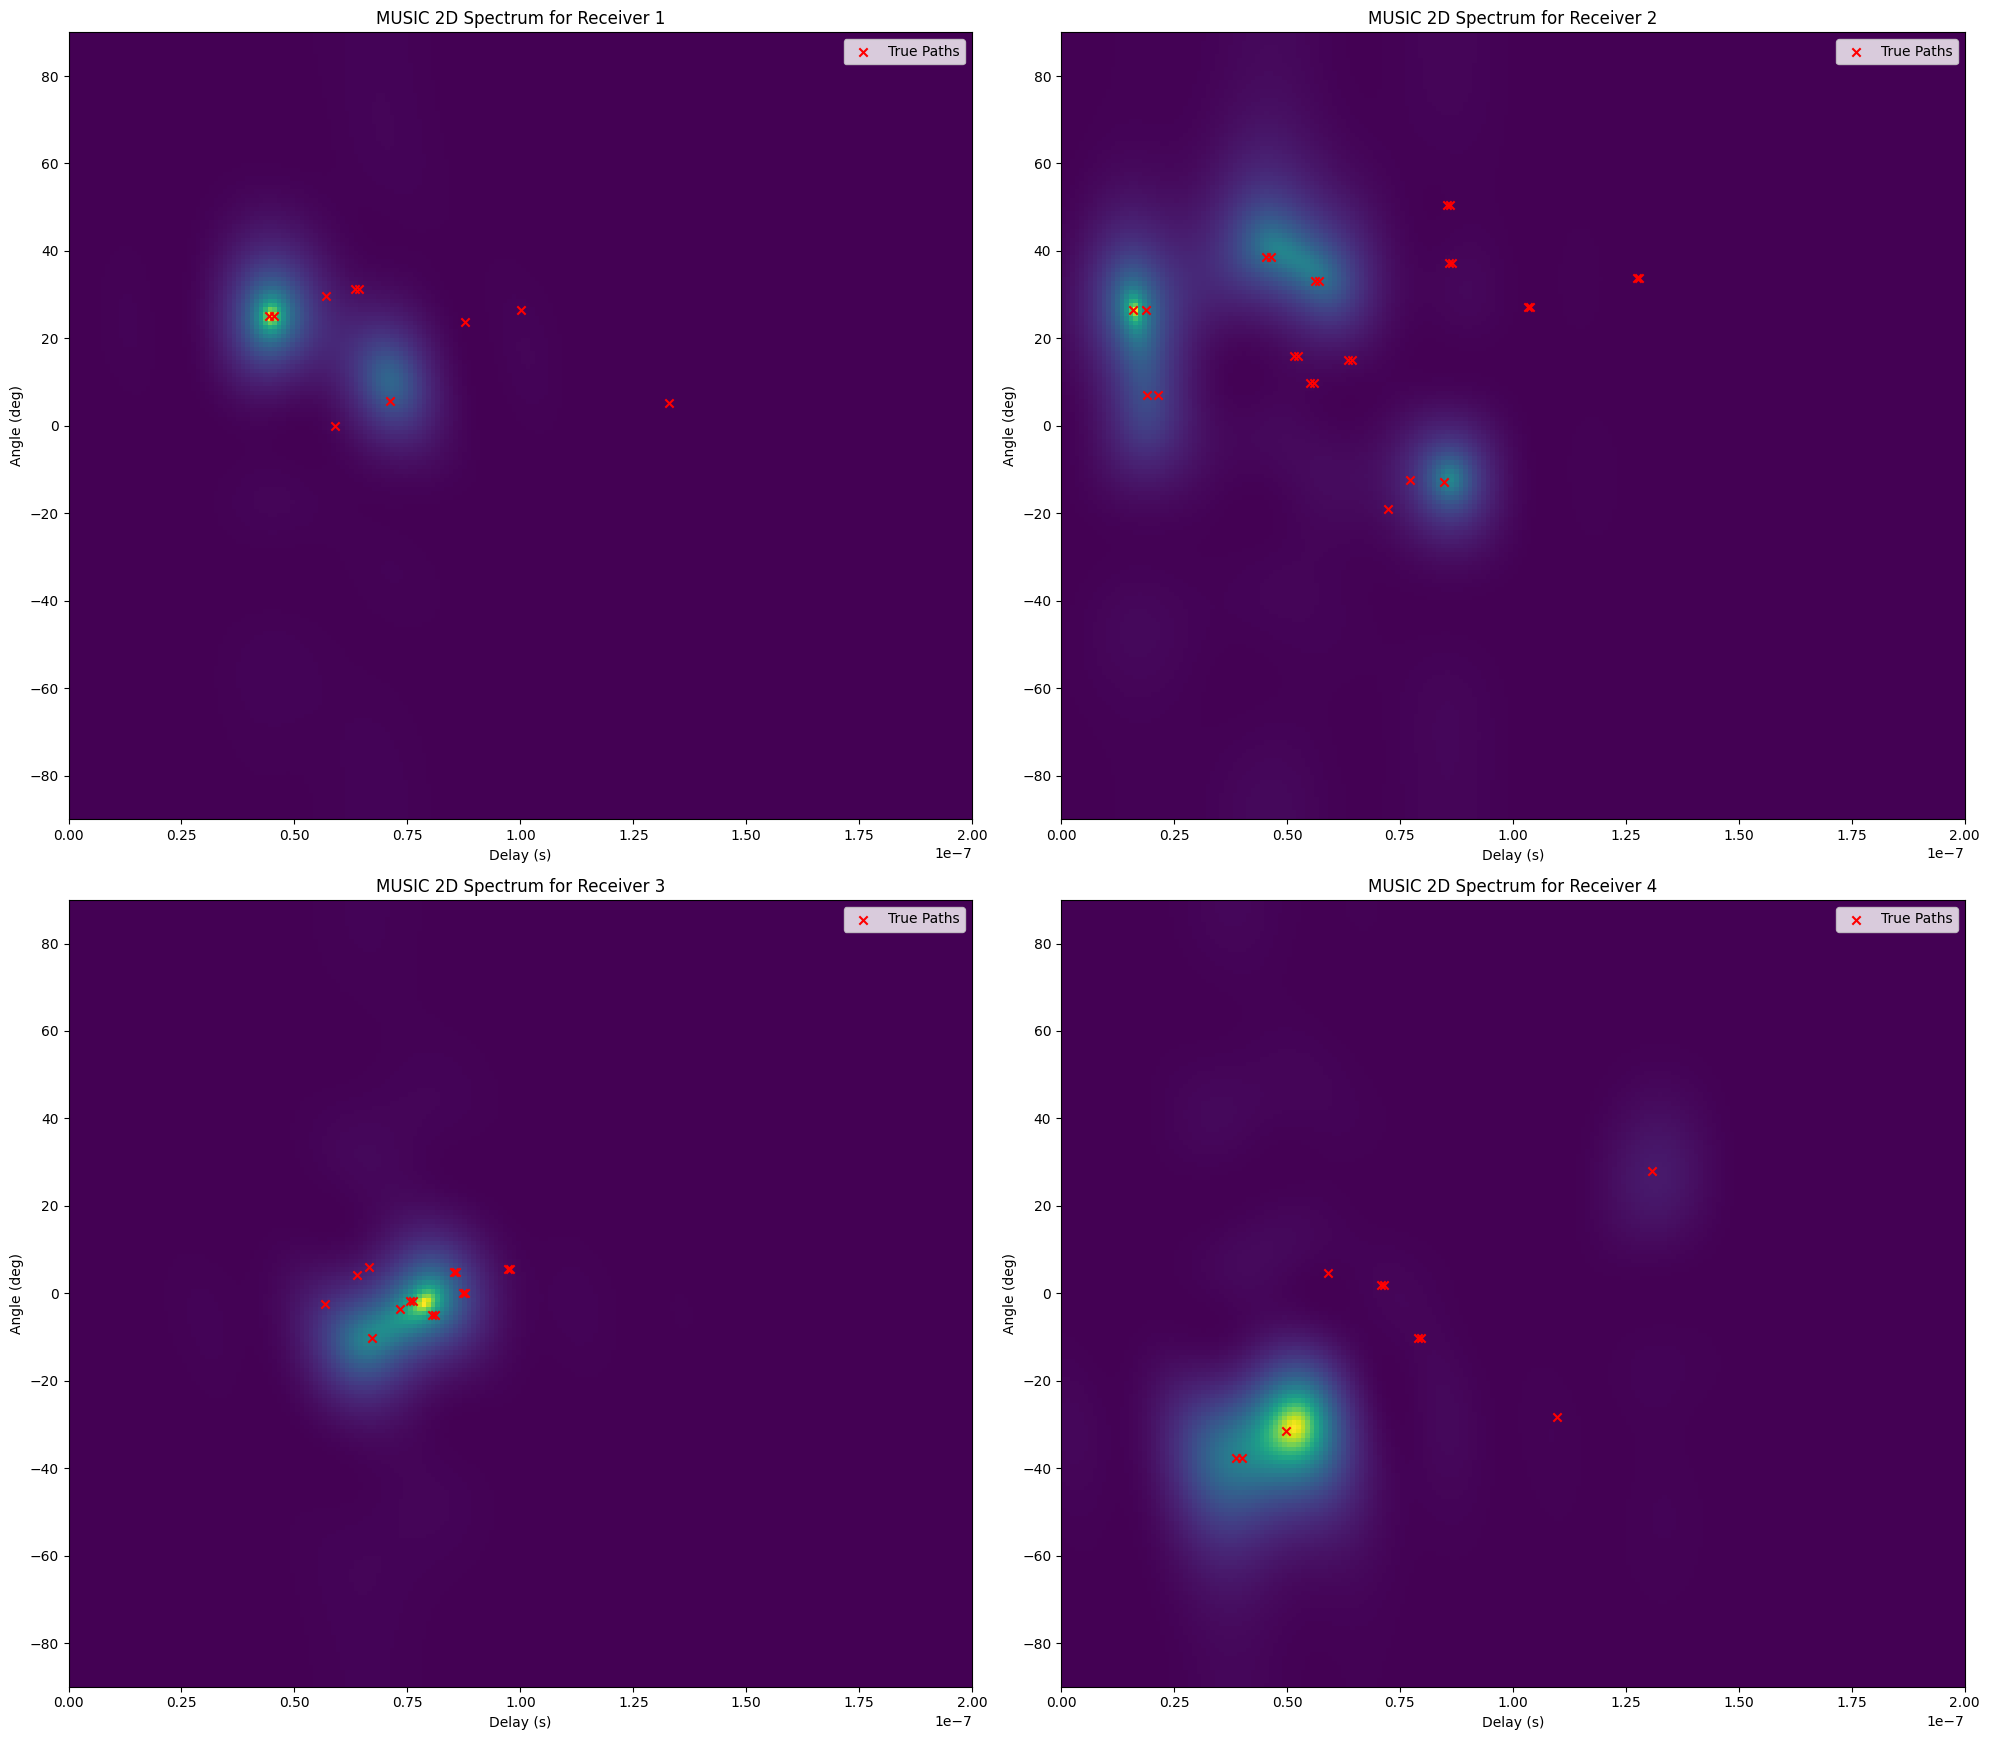

In [ ]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

In [33]:
importlib.reload(mp)

taps_hat = []
taus_hat = []
angles_hat = []
print(music_spectrums[0].shape)
for RX_idx in range(num_rx):
    music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                music_taus[RX_idx], 
                                                                                music_angles[RX_idx], 
                                                                                B/fft_size, 
                                                                                music_Ks[RX_idx], 
                                                                                music_h_hats[RX_idx])
    taps_hat.append(music_taps)
    taus_hat.append(music_estimated_taus)
    angles_hat.append(music_estimated_angles)


(360, 1000)


Estimated path amplitudes (dB): [ -99.00010244 -105.64793644 -123.50138328 -127.60286371 -118.07752651]
(5,)
Sorted delays (s): (5,)
Sorted angles (rad): (5,)
Marker sizes: (5,)


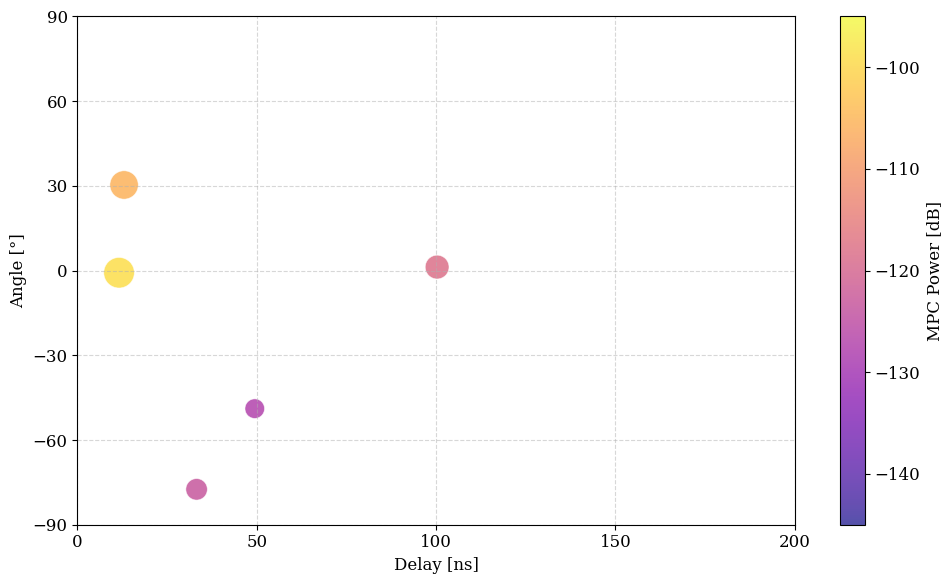

In [46]:
Rx_idx = 3

# 2. Convert amplitudes to dB (Power)
taps_amplitudes_db = 20 * np.log10(np.abs(taps_hat[Rx_idx]) + 1e-10)
print("Estimated path amplitudes (dB):", taps_amplitudes_db)
print(taps_amplitudes_db.shape)

sort_idx = np.argsort(taps_amplitudes_db)
delays_sorted = taus_hat[Rx_idx][sort_idx]
angles_sorted = angles_hat[Rx_idx][sort_idx]

print("Sorted delays (s):", delays_sorted.shape)
print("Sorted angles (rad):", angles_sorted.shape)

# 3. Normalize sizes for the scatter plot markers
# We subtract the minimum to ensure all sizes are positive, then scale up
min_db = np.min(amplitudes_db)
sizes = (taps_amplitudes_db - min_db + 5) * 10 
print("Marker sizes:", sizes.shape)

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Use scatter with both 'c' (color) and 's' (size) mapped to amplitude
scatter = plt.scatter(delays_sorted, angles_sorted*180/np.pi, 
                      c=taps_amplitudes_db[sort_idx], 
                      s=sizes[sort_idx], 
                      cmap='plasma',     # 'magma' or 'viridis' look great for power
                      alpha=0.7,        # Slight transparency for overlapping taps
                      edgecolors='white', 
                      linewidth=0.5,
                      vmin= -145, vmax=-95)  # Set color limits for better contrast

# 5. Formatting
cbar = plt.colorbar(scatter)
cbar.set_label('MPC Power [dB]')

plt.xlabel('Delay [ns]')
plt.ylabel('Angle [°]')

plt.xlim(0, 200e-9)
plt.ylim(-90, 90)

plt.xticks(np.arange(0, 201e-9, 50e-9), labels=[0, 50, 100, 150, 200])
plt.yticks(np.arange(-90, 91, 30))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("music_estimated_paths.pdf", bbox_inches='tight')
plt.show()

In [ ]:
import Aoa
import Tdoa
import Hybrid
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

true_first_toas = [tau[RX_idx][0] if len(tau[RX_idx]) > 0 else -1 for RX_idx in range(num_rx)]
true_first_aoas = [angles[RX_idx][0] if len(angles[RX_idx]) > 0 else 4 for RX_idx in range(num_rx)]

first_toas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
    first_toas[RX_idx] = first_toa

first_aoas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])


# Manual correction of wrong estimates
valid_Rxs = [True for _ in range(num_rx)]
# valid_Rxs[2] = False



# for RX_idx in range(num_rx):
#     print(f"Receiver {RX_idx+1}:")
#     print(f"  True First ToA: {true_first_toas[RX_idx]:.2e} s, Estimated First ToA: {first_toas[RX_idx]:.2e} s")
#     print(f"  True First AoA: {true_first_aoas[RX_idx]*180/np.pi:.2f} deg, Estimated First AoA: {first_aoas[RX_idx]*180/np.pi:.2f} deg")


# TDOA localization using first path
TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer2 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer3 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer4 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)

position_estimate_tdoa = TdoaLocalizer.localize()
position_estimate_tdoa2 = TdoaLocalizer2.localize_least_squares()
position_estimate_tdoa3, residuals_record = TdoaLocalizer3.localize_weighted_least_squares(iter=2)
# position_estimate_tdoa4 = TdoaLocalizer4.localize_iterative_outlier_removal(iter=2)
print("TDOA Position Estimate:", position_estimate_tdoa)
print("TDOA Least Squares Position Estimate:", position_estimate_tdoa2)
print("TDOA Weighted Least Squares Position Estimate:", position_estimate_tdoa3)
# print("TDOA Iterative Outlier Removal Position Estimate:", position_estimate_tdoa4)

# Filtering
errors = first_toas*3e8 - np.linalg.norm(np.array(RX_positions)[:,:2] - position_estimate_tdoa2, axis=1)
errors2 = TdoaLocalizer2.detect_outliers(position_estimate_tdoa2)
print("Receiver errors (m):", errors)
print("Receiver errors2 (m):", errors2)

# fig, ax = plt.subplots(1, residuals_record.shape[1], figsize=(20, 5))
# for i in range(residuals_record.shape[1]):
#     ax[i].plot(np.abs(residuals_record[:, i]))
#     ax[i].set_title(f"Residuals for TDoA {i+1}")
#     ax[i].set_xlabel("Iteration")
#     ax[i].set_ylabel("Residual (m)")
# plt.tight_layout()
# plt.show()

# for RX_idx in range(num_rx):
#     print(f"Rx position: {RX_positions[RX_idx][:2]}")
#     print(f"Distance measured from toa: {first_toas[RX_idx]*3e8:.2f} m")
#     print(f"Actual distance from target: {np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - np.array(TX_position[:2])):.2f} m")


# AOA localization using first path
AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_aoa = AoaLocalizer.localize()
position_estimate_aoa2 = AoaLocalizer.localize_least_squares()
print("AOA Position Estimate:", position_estimate_aoa)
print("AOA Least Squares Position Estimate:", position_estimate_aoa2)

TDOA Position Estimate: [4.56218874 5.8776971 ]
TDOA Least Squares Position Estimate: [4.91210078 6.19484039]
TDOA Weighted Least Squares Position Estimate: [4.53648567 5.87156557]
Receiver errors (m): [1.2182303  2.06406185 1.36866807 1.02931261]
Receiver errors2 (m): [0.85167192 0.1458489  0.19037778 0.        ]
AOA Position Estimate: [1.83298922 5.35750008]
AOA Least Squares Position Estimate: [1.83299588 5.35746715]


In [ ]:
importlib.reload(Hybrid)
importlib.reload(Tdoa)
importlib.reload(util)


HybridLocalizer2 = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
position_estimate_hybrid = HybridLocalizer2.localize()
position_estimate_hybrid_time, t0 = HybridLocalizer2.localize_time()
print("Hybrid Position Estimate with first paths only:", position_estimate_hybrid)
print("Hybrid Time-based Position Estimate:", position_estimate_hybrid_time, "with t0 =", t0)

# position_estimate_hybrid_filter = HybridLocalizer2.localize_filter()
# print("Hybrid Position Estimate with filtered paths:", position_estimate_hybrid_filter)

position_estimate_hybrid_ransac = HybridLocalizer2.localize_ransac(iter=100, threshold=0.5)
print("Hybrid Position Estimate with RANSAC:", position_estimate_hybrid_ransac)

position_estimate_hybrid_all = HybridLocalizer2.localize_all(iter=100, threshold=0.5)
print("Hybrid Position Estimate with all paths:", position_estimate_hybrid_all)

Hybrid Position Estimate with first paths only: [3.45135082 5.36485373]
Hybrid Time-based Position Estimate: [2.9978783  5.82070292] with t0 = 5.915715385019648e-09
Hybrid Position Estimate with RANSAC: [3.56465907 4.52561441]
Hybrid Position Estimate with all paths: [5.59334652 3.51109834]


### Simulation loop ###

In [7]:
import Multipath as mp
import Comm as com
import util

importlib.reload(mp)
importlib.reload(com)
importlib.reload(util)

# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')


# Rx positions
scenario = 4

# Scenario with 4 receivers
if scenario == 4:
    num_rx = 4
    RX_positions = [[-7, 8, 1.5], 
                    [7, 8, 1.5],
                    [-7, -8, 1.5],
                    [7, -8, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi/4, 0, 0],
                        [3*np.pi/4, 0, 0]]

    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])

    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)

if scenario == 6:
    num_rx = 6
    RX_positions = [[-7, 8, 1.5], 
                    [7, 8, 1.5],
                    [-7, -8, 1.5],
                    [7, -8, 1.5],
                    [-9, 0, 1.5], 
                    [9, 0, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi/4, 0, 0],
                        [3*np.pi/4, 0, 0],
                        [0, 0, 0],
                        [np.pi, 0, 0]]

    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
    rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
    rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)
    scene.add(rx5)
    scene.add(rx6)

if scenario == 8:
    num_rx = 8
    RX_positions = [[-7, 8, 1.5], 
                    [0, 8, 1.5], 
                    [7, 8, 1.5], 
                    [9, 0, 1.5], 
                    [-9, 0, 1.5], 
                    [-7, -8, 1.5], 
                    [0, -8, 1.5], 
                    [7, -8, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-np.pi/2, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi, 0, 0], 
                        [0, 0, 0], 
                        [np.pi/4, 0, 0], 
                        [np.pi/2, 0, 0], 
                        [3*np.pi/4, 0, 0]]
    
    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
    rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
    rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
    rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
    rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)
    scene.add(rx5)
    scene.add(rx6)
    scene.add(rx7)
    scene.add(rx8)

# Tx positions
TX_positions = np.zeros((8, 5, 3))
x_axis = np.linspace(-7, 7, 8)
y_axis = np.linspace(-4, 4, 5)
x_axis, y_axis = np.meshgrid(x_axis, y_axis, indexing='ij')
TX_positions[:, :, 0] = x_axis
TX_positions[:, :, 1] = y_axis
TX_positions[:, :, 2] = 1.5


### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

fft_size = 256


### Simulation ###

for iter in range(0, 10):
    for i in range(8):
        for j in range(5):
            tx = Transmitter("tx", [float(TX_positions[i, j, 0]), float(TX_positions[i, j, 1]), float(TX_positions[i, j, 2])])
            scene.add(tx)

            pathSolver = PathSolver()
            paths = pathSolver(scene=scene, max_depth=15)


            # Channel impulse response of the path
            cir = paths.cir(sampling_frequency=3.5e9,
                            num_time_steps=1,
                            normalize_delays=False)

            angles = paths.phi_r

            a, tau, angles = util.format_paths(cir, angles, array=True)

            # Scale a with transmit power
            a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

            # Energy of paths
            magnitudes = [np.abs(a[RX_idx]) for RX_idx in range(num_rx)]
            energies = [magnitudes[RX_idx]**2 for RX_idx in range(num_rx)]


            # Filter paths too weak
            threshold = -150 # in dB, relative to P_TX
            threshold_lin = 10 ** (threshold / 10)

            for RX_idx in range(num_rx):
                mask = energies[RX_idx] >= threshold_lin
                a[RX_idx] = a[RX_idx][mask].reshape(num_rx_ant, -1)
                tau[RX_idx] = tau[RX_idx][mask[0]]
                angles[RX_idx] = angles[RX_idx][mask[0]]
                magnitudes[RX_idx] = magnitudes[RX_idx][mask].reshape(num_rx_ant, -1)
                energies[RX_idx] = energies[RX_idx][mask].reshape(num_rx_ant, -1)


            music_spectrums = []
            music_taus = []
            music_angles = []
            music_Ks = []
            music_h_hats = []
            for RX_idx in range(num_rx):
                music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
                music_spectrums.append(music_spectrum)
                music_taus.append(music_tau)
                music_angles.append(music_angle)
                music_Ks.append(music_K)
                music_h_hats.append(music_h_hat)


            taps_hat = []
            taus_hat = []
            angles_hat = []
            for RX_idx in range(num_rx):
                music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                            music_taus[RX_idx], 
                                                                                            music_angles[RX_idx], 
                                                                                            B/fft_size, 
                                                                                            music_Ks[RX_idx], 
                                                                                            music_h_hats[RX_idx])
                taps_hat.append(music_taps)
                taus_hat.append(music_estimated_taus)
                angles_hat.append(music_estimated_angles)

            scene.remove("tx")

            # Write results to file
            filename = f"Small{scenario}/taps_estimates_{i}_{j}.csv"

            if iter == 0:
                util.clear_taps_file(filename)
            util.write_taps_to_csv(iter, taus_hat, angles_hat, TX_positions[i, j], RX_positions, RX_orientations, filename)

        


no-name-5      itu-concrete
elm__7         itu-glass
Cleared previous data: plot_csv\Small4/taps_estimates_0_0.csv
Cleared previous data: plot_csv\Small4/taps_estimates_0_1.csv
Cleared previous data: plot_csv\Small4/taps_estimates_0_2.csv
Cleared previous data: plot_csv\Small4/taps_estimates_0_3.csv
Cleared previous data: plot_csv\Small4/taps_estimates_0_4.csv
Cleared previous data: plot_csv\Small4/taps_estimates_1_0.csv
Cleared previous data: plot_csv\Small4/taps_estimates_1_1.csv
Cleared previous data: plot_csv\Small4/taps_estimates_1_2.csv
Cleared previous data: plot_csv\Small4/taps_estimates_1_3.csv
Cleared previous data: plot_csv\Small4/taps_estimates_1_4.csv
Cleared previous data: plot_csv\Small4/taps_estimates_2_0.csv
Cleared previous data: plot_csv\Small4/taps_estimates_2_1.csv
Cleared previous data: plot_csv\Small4/taps_estimates_2_2.csv
Cleared previous data: plot_csv\Small4/taps_estimates_2_3.csv
Cleared previous data: plot_csv\Small4/taps_estimates_2_4.csv
Cleared previous 

In [ ]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

tdoa_errors = []
aoa_errors = []
hybrid_errors = []
hybrid_ransac_errors = []
hybrid_ransac_fo_errors = []

for i in range(8):
    for j in range(5):
        filename = f"Small8/taps_estimates_{i}_{j}.csv"
        TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

        for iter in range(1):

            taus_hat = data[f'{iter}']['delays']
            angles_hat = data[f'{iter}']['angles']

            first_toas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                first_toas[RX_idx] = first_toa

            first_aoas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

            # TDOA localization using first path
            TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
            position_estimate_tdoa = TdoaLocalizer.localize()
            tdoa_errors.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))

            # AOA localization using first path
            AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
            position_estimate_aoa = AoaLocalizer.localize_least_squares()
            aoa_errors.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))

            # Hybrid localization
            HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
            position_estimate_hybrid = HybridLocalizer.localize()
            hybrid_errors.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))

            # Hybrid localization with RANSAC
            position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(iter=100, threshold=0.5)
            hybrid_ransac_errors.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))

            # Hybrid localization with RANSAC + first-order reflections
            try:
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_iterative2(iter=100, threshold=0.5)
                hybrid_ransac_fo_errors.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
            except Exception as e:
                print(f"Error occurred while localizing with RANSAC + FO: {e}")
                print(taus_hat)

Ransac iteration: nb_inliers = 19
Ransac iteration: nb_inliers = 22
Ransac iteration: nb_inliers = 22
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 14
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 12
Ransac iteration: nb_inliers = 14
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iterati

RMSE TDOA: 184754046.53 m
RMSE AOA: 5.23 m
RMSE Hybrid: 1.87 m
RMSE Hybrid RANSAC: 0.36 m
RMSE Hybrid RANSAC FO: 0.25 m


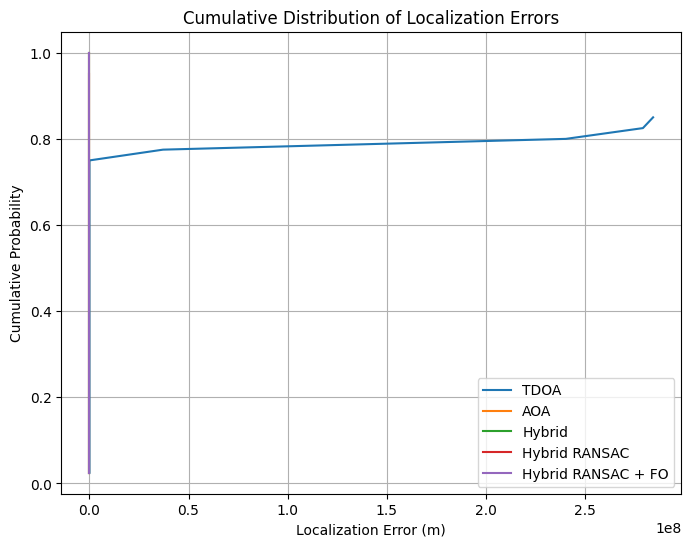

In [ ]:
tdoa_errors = np.array(tdoa_errors)
aoa_errors = np.array(aoa_errors)
hybrid_errors = np.array(hybrid_errors)
hybrid_ransac_errors = np.array(hybrid_ransac_errors)
hybrid_ransac_fo_errors = np.array(hybrid_ransac_fo_errors)

rmse_tdoa = np.sqrt(np.mean(tdoa_errors**2))
rmse_aoa = np.sqrt(np.mean(aoa_errors**2))
rmse_hybrid = np.sqrt(np.mean(hybrid_errors**2))
rmse_hybrid_ransac = np.sqrt(np.mean(hybrid_ransac_errors**2))
rmse_hybrid_ransac_fo = np.sqrt(np.mean(hybrid_ransac_fo_errors**2))

print(f"RMSE TDOA: {rmse_tdoa:.2f} m")
print(f"RMSE AOA: {rmse_aoa:.2f} m")
print(f"RMSE Hybrid: {rmse_hybrid:.2f} m")
print(f"RMSE Hybrid RANSAC: {rmse_hybrid_ransac:.2f} m")
print(f"RMSE Hybrid RANSAC FO: {rmse_hybrid_ransac_fo:.2f} m")

cum = np.arange(1, len(tdoa_errors)+1) / len(tdoa_errors)

tdoa_errors_sorted = np.sort(tdoa_errors)
aoa_errors_sorted = np.sort(aoa_errors)
hybrid_errors_sorted = np.sort(hybrid_errors)
hybrid_ransac_errors_sorted = np.sort(hybrid_ransac_errors)
hybrid_ransac_fo_errors_sorted = np.sort(hybrid_ransac_fo_errors)

plt.figure(figsize=(8, 6))
plt.plot(tdoa_errors_sorted[:-6], cum[:-6], label='TDOA')
plt.plot(aoa_errors_sorted, cum, label='AOA')
plt.plot(hybrid_errors_sorted, cum, label='Hybrid')
plt.plot(hybrid_ransac_errors_sorted[:-2], cum[:-2], label='Hybrid RANSAC')
plt.plot(hybrid_ransac_fo_errors_sorted, cum, label='Hybrid RANSAC + FO')
plt.xlabel("Localization Error (m)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Localization Errors")
plt.legend()
plt.grid()
plt.show()
